# Weather Regimes

In [1]:
source("../RScripts/config.r")
source("../RScripts/plot_functions.r")
source("../RScripts/data_functions.r")
source("../RScripts/algo_functions.r")


options(repr.plot.width = 15, repr.plot.height = 10) # Adjust width & height


Linking to GEOS 3.11.1, GDAL 3.6.2, PROJ 9.1.1; sf_use_s2() is TRUE

Lade nötiges Paket: maps


Attache Paket: ‘rnaturalearthdata’


Das folgende Objekt ist maskiert ‘package:rnaturalearth’:

    countries110


Lade nötiges Paket: abind


Attache Paket: ‘dplyr’


Die folgenden Objekte sind maskiert von ‘package:stats’:

    filter, lag


Die folgenden Objekte sind maskiert von ‘package:base’:

    intersect, setdiff, setequal, union



Attache Paket: ‘purrr’


Das folgende Objekt ist maskiert ‘package:scales’:

    discard


Das folgende Objekt ist maskiert ‘package:maps’:

    map



Attache Paket: ‘lubridate’


Das folgende Objekt ist maskiert ‘package:cowplot’:

    stamp


Die folgenden Objekte sind maskiert von ‘package:base’:

    date, intersect, setdiff, union



Attache Paket: ‘data.table’


Die folgenden Objekte sind maskiert von ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Das folgende Objekt ist maskiert ‘packag

In [ ]:
result <- wrera(
    start = "19500111_00",
    end = "20250113_21",
    hours = c("12"),
    tformat = "string",
    setup = "z500anom_1979_2019_on_wrdef_10d_1.0_1979_2019",
    dataset = "era5",
    basepath = "../WR_read_example_package/wr_era5_update_1950_latwgt/"
)

wr_df <- result$data$LC
wr_df$date <- as.Date(wr_df$time)
str(wr_df)


Classes ‘data.table’ and 'data.frame':	27397 obs. of  5 variables:
 $ tsince : int  -253956 -253932 -253908 -253884 -253860 -253836 -253812 -253788 -253764 -253740 ...
 $ time   : POSIXct, format: "1950-01-11 12:00:00" "1950-01-12 12:00:00" ...
 $ wrindex: Factor w/ 8 levels "1","6","7","2",..: 8 8 8 8 8 8 5 5 5 5 ...
 $ wrname : Factor w/ 8 levels "AT","ZO","ScTr",..: 8 8 8 8 8 8 5 5 5 5 ...
 $ date   : Date, format: "1950-01-11" "1950-01-12" ...
 - attr(*, ".internal.selfref")=<externalptr> 


In [2]:
wr_min <- readRDS("../data/wrnames.rds")


In [3]:
str(wr_min)


'data.frame':	27397 obs. of  2 variables:
 $ date  : Date, format: "1950-01-11" "1950-01-12" ...
 $ wrname: Factor w/ 8 levels "AT","ZO","ScTr",..: 8 8 8 8 8 8 5 5 5 5 ...


In [15]:
arrange_blocks_no_adjacent <- function(values,
                                       max_attempts = 100L) {
    k <- length(values)
    if (k <= 1L) {
        return(seq_len(k))
    }

    cat_counts_init <- table(values)
    if (max(cat_counts_init) > (k + 1L) %/% 2L) {
        return(NULL)
    }

    for (attempt in seq_len(max_attempts)) {
        by_cat <- split(seq_len(k), values)
        counts <- vapply(by_cat, length, integer(1L))

        result <- integer(k)
        last_cat <- ""
        failed <- FALSE

        for (pos in seq_len(k)) {
            rem <- k - pos + 1L
            available <- names(counts)[counts > 0L &
                names(counts) != last_cat]

            if (length(available) == 0L) {
                failed <- TRUE
                break
            }

            avail_counts <- counts[available]
            must_place <- available[avail_counts > rem %/% 2L]

            chosen_cat <- if (length(must_place) > 0L) {
                if (length(must_place) > 1L) {
                    sample(must_place, 1L)
                } else {
                    must_place
                }
            } else if (length(available) > 1L) {
                sample(available, 1L, prob = avail_counts)
            } else {
                available
            }

            pool <- by_cat[[chosen_cat]]
            chosen <- if (length(pool) > 1L) {
                sample(pool, 1L)
            } else {
                pool
            }

            result[pos] <- chosen
            by_cat[[chosen_cat]] <- pool[pool != chosen]
            counts[chosen_cat] <- counts[chosen_cat] - 1L
            last_cat <- chosen_cat
        }

        if (!failed) {
            return(result)
        }
    }

    NULL
}

permute_wr_blocks <- function(wrname_vec, gap_label = "no") {
    blocks <- rle(as.character(wrname_vec))
    is_gap <- blocks$values == gap_label

    named_values <- blocks$values[!is_gap]
    named_lengths <- blocks$lengths[!is_gap]
    gap_lengths <- blocks$lengths[is_gap]

    k <- length(named_values)
    g <- length(gap_lengths)

    if (k <= 1L) {
        return(factor(wrname_vec))
    }

    perm_idx <- arrange_blocks_no_adjacent(named_values)
    if (is.null(perm_idx)) {
        warning("Infeasible WR sequence; returning original")
        return(factor(wrname_vec))
    }

    new_named_values <- named_values[perm_idx]
    new_named_lengths <- named_lengths[perm_idx]

    n_slots <- k + 1L
    if (g > n_slots) stop("More 'no' blocks than slots")

    chosen_slots <- sort(sample.int(n_slots, g))
    shuffled_gap_lengths <- sample(gap_lengths)

    new_values <- character(0)
    new_lengths <- integer(0)
    gap_idx <- 1L

    for (slot in seq_len(n_slots)) {
        if (slot %in% chosen_slots) {
            new_values <- c(new_values, gap_label)
            new_lengths <- c(
                new_lengths,
                shuffled_gap_lengths[gap_idx]
            )
            gap_idx <- gap_idx + 1L
        }
        if (slot <= k) {
            new_values <- c(new_values, new_named_values[slot])
            new_lengths <- c(new_lengths, new_named_lengths[slot])
        }
    }

    factor(inverse.rle(list(
        lengths = new_lengths,
        values = new_values
    )))
}

verify_permutation <- function(original, n_trials = 20L) {
    orig_blocks <- rle(as.character(original))
    orig_dist <- lapply(split(
        orig_blocks$lengths,
        orig_blocks$values
    ), sort)

    for (i in seq_len(n_trials)) {
        perm <- permute_wr_blocks(original)
        perm_blocks <- rle(as.character(perm))
        perm_dist <- lapply(split(
            perm_blocks$lengths,
            perm_blocks$values
        ), sort)

        if (identical(
            as.character(perm),
            as.character(original)
        )) {
            stop("Trial ", i, ": permuted equals original")
        }
        if (!identical(orig_dist, perm_dist)) {
            stop("Trial ", i, ": block length dist changed")
        }
        nv <- perm_blocks$values
        if (length(nv) > 1L &&
            any(nv[-1L] == nv[-length(nv)])) {
            stop("Trial ", i, ": adjacent same categories")
        }
        if (length(perm) != length(original)) {
            stop("Trial ", i, ": length changed")
        }
    }
    message("All ", n_trials, " trials passed")
    invisible(TRUE)
}


In [17]:
verify_permutation(wr_min$wrname, n_trials = 100L)


All 100 trials passed



In [8]:
wrname_vec <- wr_min$wrname
gap_label <- "no"
blocks <- rle(as.character(wrname_vec))
is_gap <- blocks$values == gap_label

named_values <- blocks$values[!is_gap]
named_lengths <- blocks$lengths[!is_gap]
gap_lengths <- blocks$lengths[is_gap]

k <- length(named_values)
g <- length(gap_lengths)


In [12]:
perm <- sample.int(k)
perm_vals <- named_values[perm]


In [14]:
perm_vals


[1] "ScTr" "ZO"   "GL"   "EuBL" "ZO"   "ScBL" "ZO"   "AR"   "ScBL" "GL"  
  [11] "ZO"   "ScTr" "EuBL" "ScBL" "ScBL" "ZO"   "ScTr" "EuBL" "AR"   "ScBL"
  [21] "EuBL" "ScBL" "ScTr" "AT"   "EuBL" "ZO"   "AT"   "EuBL" "ZO"   "EuBL"
  [31] "ScTr" "EuBL" "GL"   "ZO"   "GL"   "ZO"   "AT"   "EuBL" "GL"   "EuBL"
  [41] "AR"   "GL"   "ScTr" "ScBL" "ScTr" "AR"   "ScTr" "AR"   "ScTr" "AT"  
  [51] "GL"   "ZO"   "GL"   "EuBL" "GL"   "AR"   "AT"   "EuBL" "GL"   "ScBL"
  [61] "ZO"   "ZO"   "AT"   "ZO"   "AT"   "ScTr" "ScTr" "ScBL" "EuBL" "GL"  
  [71] "ScTr" "AT"   "AR"   "AT"   "AR"   "AT"   "AR"   "ScTr" "AR"   "GL"  
  [81] "ScBL" "ScTr" "AR"   "AT"   "ScBL" "ScBL" "ZO"   "ZO"   "ZO"   "ScTr"
  [91] "EuBL" "AR"   "ZO"   "AT"   "AR"   "GL"   "EuBL" "GL"   "GL"   "AT"  
 [101] "GL"   "EuBL" "ScBL" "AT"   "AT"   "ZO"   "ScBL" "ScBL" "EuBL" "ScTr"
 [111] "ZO"   "ScTr" "GL"   "AT"   "ScBL" "AT"   "EuBL" "ScTr" "ScBL" "AT"  
 [121] "GL"   "GL"   "ScBL" "EuBL" "AR"   "ZO"   "AT"   "ZO"   "ScTr" "ScTr"
 [131] "ScBL" "ScBL" "EuBL" "ScTr" "AT"   "ScBL" "EuBL" "AR"   "EuBL" "ScBL"
 [141] "ScBL" "ScBL" "EuBL" "AT"   "AR"   "GL"   "EuBL" "ZO"   "EuBL" "GL"  
 [151] "ZO"   "ZO"   "ZO"   "GL"   "AT"   "AR"   "GL"   "GL"   "AR"   "EuBL"
 [161] "ScBL" "ScTr" "EuBL" "AR"   "EuBL" "ZO"   "ScTr" "AR"   "AR"   "AR"  
 [171] "ScBL" "ScTr" "AT"   "AR"   "GL"   "GL"   "GL"   "AT"   "ZO"   "ScTr"
 [181] "ScTr" "ScTr" "AR"   "ScTr" "GL"   "ZO"   "EuBL" "GL"   "AR"   "ZO"  
 [191] "ScBL" "AR"   "AR"   "EuBL" "ScBL" "AT"   "EuBL" "ScBL" "ScTr" "EuBL"
 [201] "ScBL" "ZO"   "ScBL" "ScBL" "AR"   "ScBL" "ZO"   "ZO"   "AT"   "AT"  
 [211] "ZO"   "GL"   "ScTr" "AT"   "ScTr" "ScTr" "AR"   "ScTr" "GL"   "ScBL"
 [221] "EuBL" "ScTr" "ScTr" "GL"   "EuBL" "AR"   "ZO"   "AR"   "ScTr" "ZO"  
 [231] "GL"   "EuBL" "AR"   "GL"   "ScBL" "ZO"   "AT"   "GL"   "GL"   "EuBL"
 [241] "ScTr" "GL"   "ScBL" "AR"   "ScTr" "AR"   "ScBL" "EuBL" "AT"   "AT"  
 [251] "AR"   "ScTr" "EuBL" "AR"   "EuBL" "GL"   "GL"   "AT"   "AR"   "ScTr"
 [261] "ScBL" "AT"   "EuBL" "GL"   "AR"   "AT"   "GL"   "EuBL" "AR"   "GL"  
 [271] "ZO"   "AT"   "ZO"   "GL"   "AT"   "ScBL" "GL"   "ScBL" "ScTr" "ZO"  
 [281] "ScTr" "AT"   "AT"   "EuBL" "AR"   "EuBL" "EuBL" "ScTr" "ScTr" "ZO"  
 [291] "ScBL" "GL"   "ZO"   "ZO"   "GL"   "EuBL" "AT"   "ZO"   "ScBL" "ScTr"
 [301] "AR"   "ScTr" "ScBL" "AT"   "ZO"   "AR"   "EuBL" "AR"   "GL"   "AR"  
 [311] "EuBL" "EuBL" "ZO"   "GL"   "ZO"   "AR"   "AR"   "ZO"   "AT"   "ScBL"
 [321] "AT"   "EuBL" "GL"   "AT"   "ScBL" "AR"   "AT"   "ScTr" "ScTr" "ScBL"
 [331] "EuBL" "ScBL" "ScTr" "ScBL" "GL"   "ScTr" "ScTr" "ZO"   "EuBL" "EuBL"
 [341] "ScTr" "AR"   "GL"   "EuBL" "ZO"   "AR"   "GL"   "EuBL" "ZO"   "AT"  
 [351] "ScBL" "ScBL" "ScBL" "AR"   "ScTr" "ZO"   "ZO"   "ScTr" "GL"   "GL"  
 [361] "EuBL" "ScTr" "AT"   "ScBL" "GL"   "ScTr" "ZO"   "AR"   "GL"   "AT"  
 [371] "AT"   "ScBL" "ZO"   "GL"   "AT"   "EuBL" "GL"   "GL"   "ScBL" "ScBL"
 [381] "EuBL" "ScBL" "ScTr" "ZO"   "ScTr" "ZO"   "ZO"   "GL"   "ScTr" "AR"  
 [391] "ScTr" "GL"   "ScTr" "EuBL" "AR"   "ZO"   "GL"   "EuBL" "GL"   "EuBL"
 [401] "EuBL" "ZO"   "AT"   "AT"   "AT"   "AR"   "ZO"   "AR"   "ScTr" "AR"  
 [411] "AT"   "GL"   "ScTr" "ZO"   "AT"   "EuBL" "ScTr" "EuBL" "ScBL" "EuBL"
 [421] "EuBL" "AR"   "ScBL" "AR"   "GL"   "ScTr" "ScBL" "EuBL" "AR"   "ScTr"
 [431] "AT"   "ZO"   "EuBL" "ZO"   "ScTr" "EuBL" "AT"   "AT"   "GL"   "ZO"  
 [441] "ZO"   "ScTr" "AR"   "AR"   "GL"   "GL"   "EuBL" "GL"   "ZO"   "ScBL"
 [451] "AT"   "ScBL" "ScBL" "EuBL" "AR"   "ScBL" "ZO"   "EuBL" "AT"   "ScTr"
 [461] "GL"   "ScBL" "EuBL" "AT"   "ScTr" "EuBL" "ScBL" "AR"   "GL"   "EuBL"
 [471] "GL"   "ZO"   "ScTr" "AR"   "ScBL" "AR"   "ScTr" "AT"   "ScTr" "AT"  
 [481] "ScBL" "AT"   "ZO"   "ScTr" "EuBL" "ScBL" "ZO"   "EuBL" "AR"   "ScTr"
 [491] "AT"   "ScTr" "ZO"   "AT"   "ScTr" "ZO"   "ScBL" "AT"   "ZO"   "AR"  
 [501] "ScBL" "GL"   "AT"   "EuBL" "AR"   "ZO"   "ScTr" "EuBL" "ScTr" "GL"  
 [511] "EuBL" "GL"   "ScTr" "ZO"   "EuBL" "EuBL" "ScTr" "GL"   "GL"   "GL"  

pdf 
  2

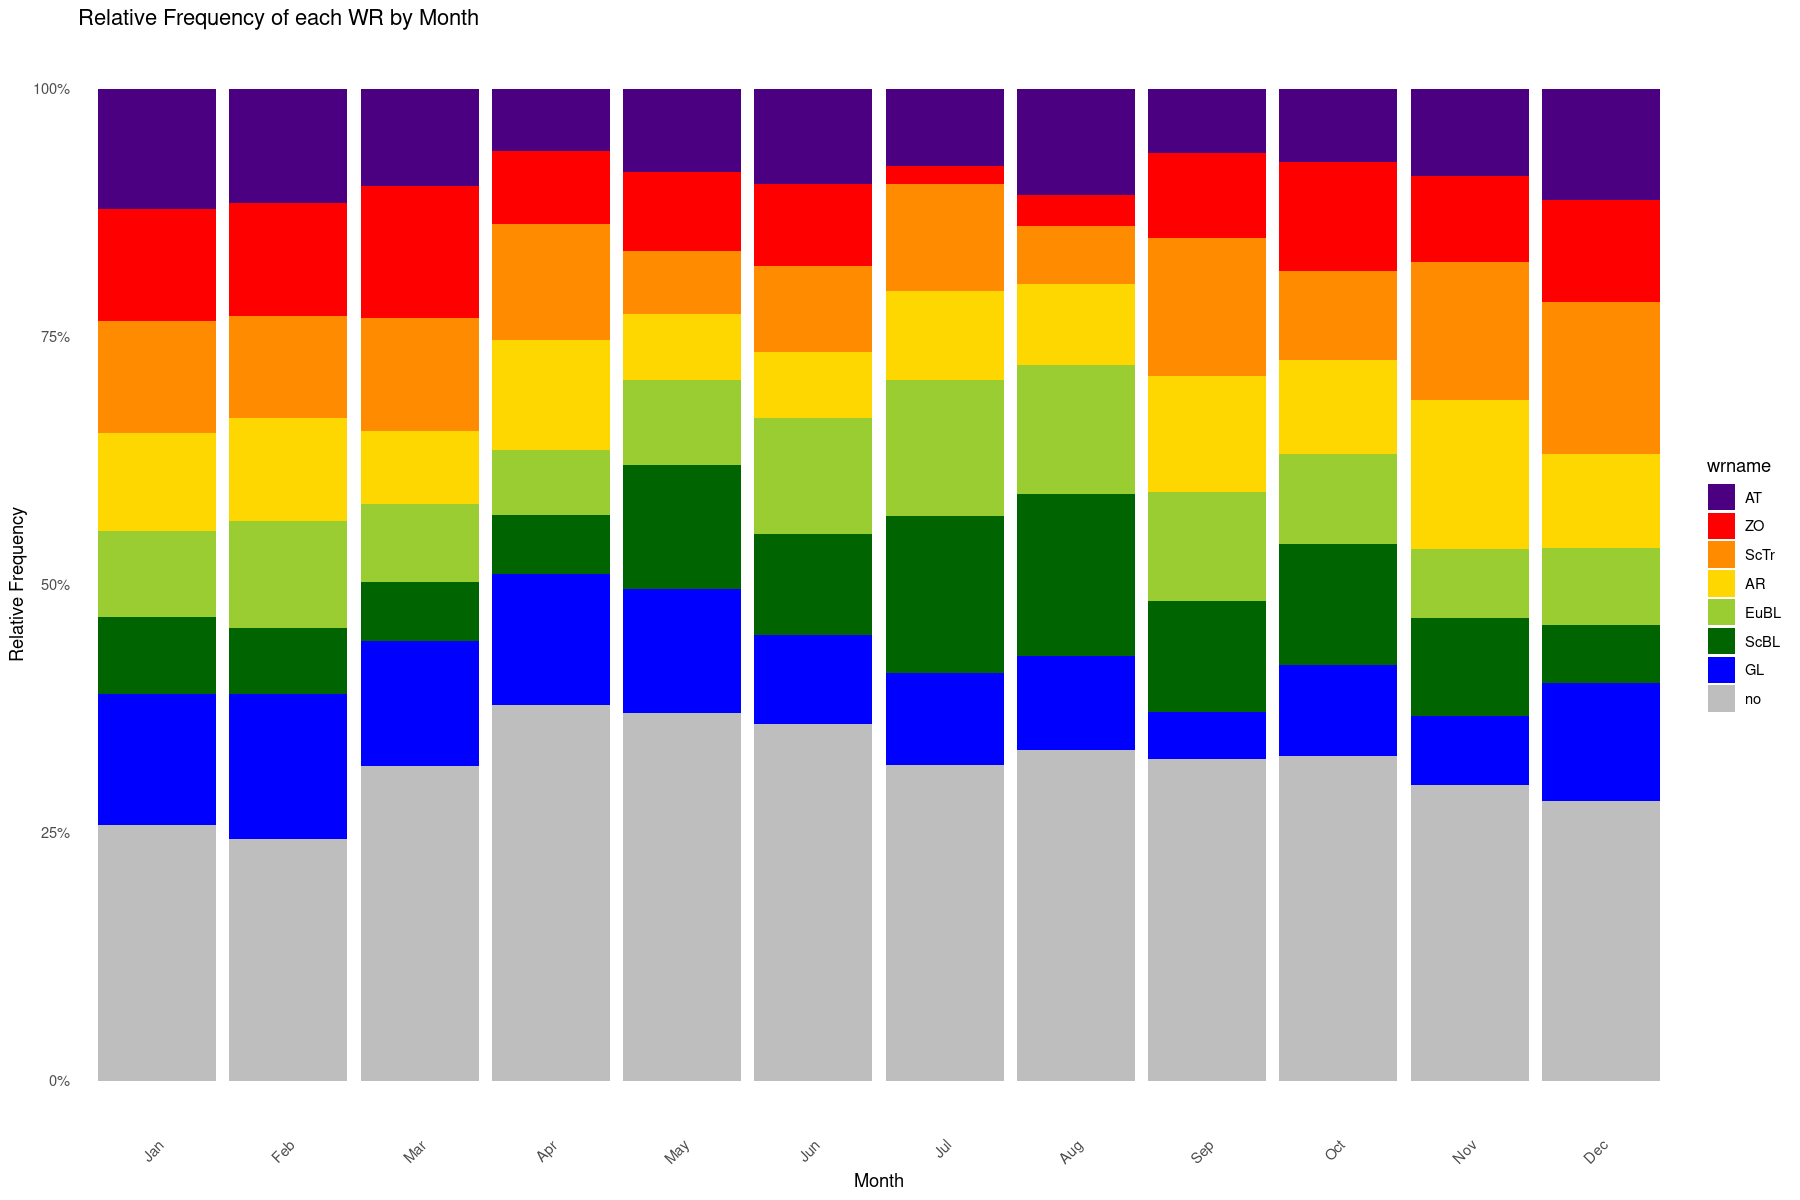

In [ ]:
df_monthly <- wr_df %>%
    mutate(
        month = lubridate::month(date, label = TRUE, abbr = TRUE)
    ) %>%
    count(month, wrname) %>% # Count occurrences by month and wrname
    group_by(month) %>%
    mutate(
        total_month = sum(n),
        rel_freq = n / total_month # Calculate relative frequency within each month
    ) %>%
    ungroup()

# Create the stacked bar chart
p <- ggplot(df_monthly, aes(x = month, y = rel_freq, fill = wrname)) +
    geom_col(position = "stack") +
    scale_fill_manual(values = COLORS_REGIMES) + # Apply custom colors
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Relative Frequency of each WR by Month",
        x = "Month",
        y = "Relative Frequency",
        fill = "wrname"
    ) +
    theme_minimal() +
    theme(
        panel.grid = element_blank(), # Remove all grid lines
        axis.text.x = element_text(angle = 45, hjust = 1) # Rotate month names if needed
    )

p
save_plot(p + THEME_PUB_LARGE, "RelFreqAll.pdf", width = 8, height = 6)


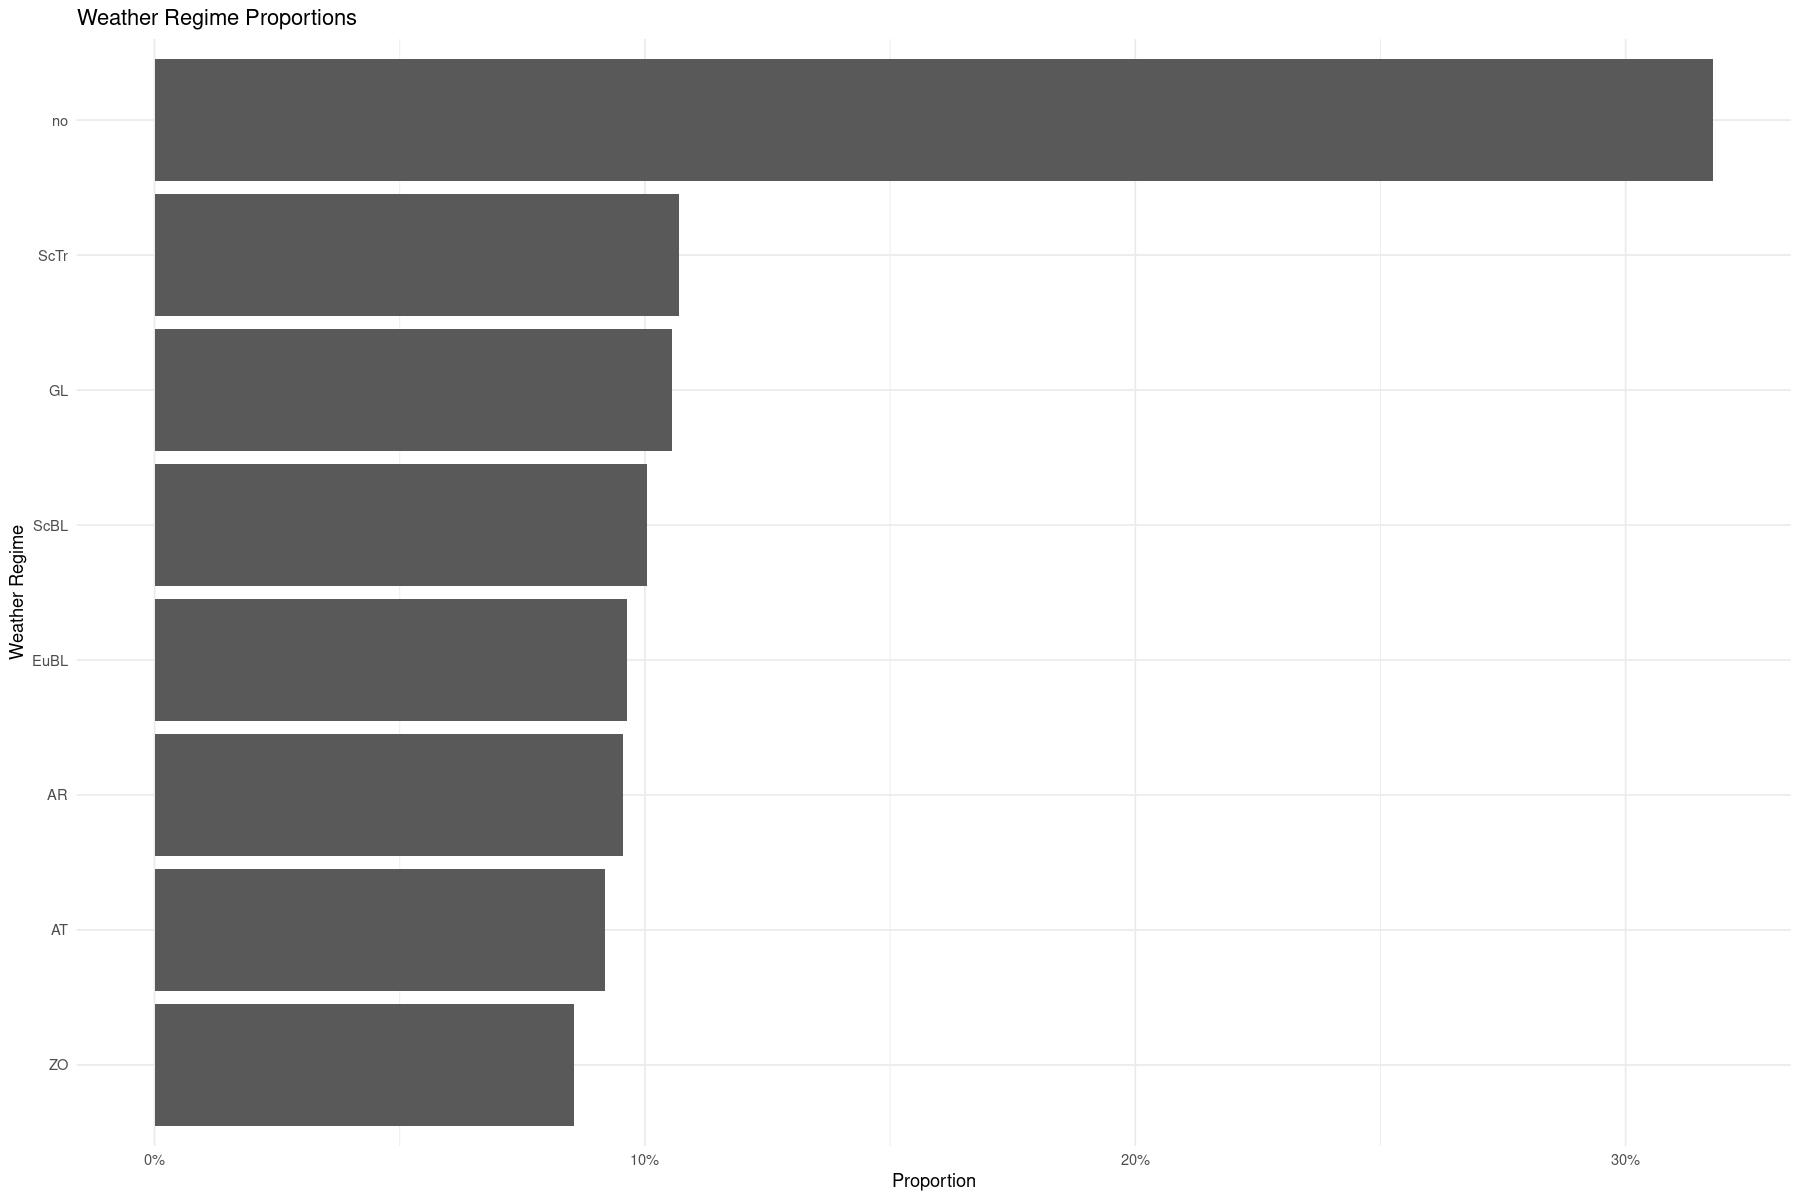

In [ ]:
result$data$LC %>%
    group_by(wrname) %>%
    summarise(n = n()) %>%
    arrange(desc(n)) %>%
    mutate(prop = n / sum(n)) %>%
    ungroup() %>%
    mutate(wrname = factor(wrname, levels = rev(wrname))) %>%
    ggplot(aes(x = wrname, y = prop)) +
    geom_col() +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    labs(
        x = "Weather Regime",
        y = "Proportion",
        title = "Weather Regime Proportions"
    ) +
    theme_minimal()


# Do some composites
1. Get time series of WRs (see above)
2. write a function get_composite_df, which
    1. takes WR time series, (S)LM_DIR
    2. cycles through WRs
        1. for each WR select dates
        2. for each grid point average residuals
    3. returns a df with columns lat, lon, WR, value
3. estimate significance through permutation test
4. plot using plot_spatial (adjust if necessary)
5. add contours of the WR (adjust if necessary)

In [ ]:
# Get the z data
# Open the file
nc <- nc_open("../data/geopotential.nc")

# Use the first occurrence (modify if needed)
lon <- ncvar_get(nc, "longitude")
lat <- ncvar_get(nc, "latitude")
time_data <- ncvar_get(nc, "valid_time")
time_origin <- sub(
    "seconds since ", "",
    ncatt_get(nc, "valid_time", "units")$value
)
time_whole <- as.Date(as.POSIXct(time_data,
    origin = time_origin,
    tz = "UTC"
))

start_vec <- c(1, 1, 1)
count_vec <- c(-1, -1, -1)
z <- ncvar_get(nc, "z", start = start_vec, count = count_vec)

nc_close(nc)

str(z)


 num [1:241, 1:121, 1:31047] 51737 51737 51737 51737 51737 ...


In [ ]:
z_comp < -calculate_wr_composites(z, time_whole, lon, lat, wr_df)


In [14]:
# comp_df_emm <- left_join(comp_df_emm, comp_df %>% select(lon, lat, wrname, z_g), by = c("lon", "lat", "wrname"))
comp_df_emm$wrname <- factor(comp_df_emm$wrname, levels = levels(wr_min$wrname))
saveRDS(comp_df_emm, "../ens_data/wr_1stemmeans.rds")


In [13]:
levels(comp_df_emm$wrname)


[1] "AT"   "ZO"   "ScTr" "AR"   "EuBL" "ScBL" "GL"   "no"

In [5]:
str(comp_df_emm)


tibble [233,288 × 11] (S3: tbl_df/tbl/data.frame)
 $ lon           : num [1:233288] -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -1.5 -1.5 ...
 $ lat           : num [1:233288] 30 30 30 30 30 30 30 30 30 30 ...
 $ wrname        : chr [1:233288] "AT" "ZO" "ScTr" "AR" ...
 $ composite_mean: num [1:233288] -0.027104 -0.003877 -0.000255 -0.001744 0.022854 ...
 $ SE            : num [1:233288] 0.00702 0.00728 0.0066 0.00693 0.00688 ...
 $ df            : num [1:233288] 27332 27332 27332 27332 27332 ...
 $ t_ratio       : num [1:233288] -3.8601 -0.5324 -0.0386 -0.2515 3.3238 ...
 $ p_value       : num [1:233288] 0.000909 0.951145 0.96922 0.96922 0.003556 ...
 $ emmean        : num [1:233288] 2.54 2.56 2.56 2.56 2.59 ...
 $ p_value_adj   : num [1:233288] 0.00245 0.96602 0.98161 0.97957 0.00789 ...
 $ z_g           : num [1:233288] 5831 5793 5795 5782 5810 ...


In [3]:
comp_df_emm2nd <- readRDS("../ens_data/wr_2ndemmeans.rds")
comp_df <- readRDS("../ens_data/composites_permuted.RDS")
comp_df_emm <- readRDS("../ens_data/wr_1stemmeans.rds")

head(comp_df_emm2nd)
str(comp_df_emm2nd)


lon,lat,wrname,emmean,p_value,p_value_adj,z_g
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
-80,30,AT,9.019086e-03,0.2245325,0.3175762,5806.942
-80,30,ZO,-1.260416e-02,0.1012634,0.1590058,5824.308
-80,30,ScTr,-5.253297e-05,0.9939164,0.9956378,5802.707
-80,30,AR,-5.470880e-03,0.4521122,0.5493733,5809.682
-80,30,EuBL,7.440091e-03,0.3045750,0.3659207,5841.836
-80,30,ScBL,5.717147e-03,0.4216954,0.5563863,5833.808


tibble [231,360 × 7] (S3: tbl_df/tbl/data.frame)
 $ lon        : num [1:231360] -80 -80 -80 -80 -80 -80 -80 -80 -80 -80 ...
 $ lat        : num [1:231360] 30 30 30 30 30 30 30 30 30.5 30.5 ...
 $ wrname     : Factor w/ 8 levels "AT","ZO","ScTr",..: 1 2 3 4 5 6 7 8 1 2 ...
 $ emmean     : num [1:231360] 9.02e-03 -1.26e-02 -5.25e-05 -5.47e-03 7.44e-03 ...
 $ p_value    : num [1:231360] 0.225 0.101 0.994 0.452 0.305 ...
 $ p_value_adj: num [1:231360] 0.318 0.159 0.996 0.549 0.366 ...
 $ z_g        : num [1:231360] 5807 5824 5803 5810 5842 ...


### Whats the variability between the WR patterns?

In [5]:
result <- comp_df %>%
    select(lon, lat, z_g) %>%
    group_by(lon, lat) %>%
    summarise(std_z_g = sd(z_g, na.rm = TRUE), .groups = "drop")


In [8]:
p <- plot_map_fast(result, "std_z_g", colorbar_title = "$m^2 / s^2$")
save_plot(p, "WRStd_z_g.pdf", height = 2.75, width = 3)


although coordinates are longitude/latitude, st_union assumes that they are
planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


pdf 
  2

# Now with permutation test

In [31]:
p <- plot_map_faceted(
    df = comp_df_emm2nd,
    var = emmean,
    facet_var = wrname,
    use_diverging = TRUE,
    p_val = p_value_adj,
    sig_threshold = 0.05,
    c_bar_label = "$\\log(\\sigma_{EDA})$",
    contour_var = z_g,
    contour_bin_width = 80,
    facet_nrow = 4
) + THEME_PUB_LARGE + ggplot2::theme(
    panel.spacing = ggplot2::unit(0.25, "lines"),
    strip.text = ggplot2::element_blank(),
    strip.background = ggplot2::element_blank(),
    # strip.placement = "outside",
    # strip.text = ggplot2::element_text(
    #     face   = "bold",
    #     margin = ggplot2::margin(b = .5, unit = "lines") # reduce bottom margin
    # ),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box.margin = ggplot2::margin(t = -.5, unit = "lines"),
    legend.margin = ggplot2::margin(0, 0, 0, 0),
    axis.text.x = ggplot2::element_blank(),
    axis.text.y = ggplot2::element_blank(),
    axis.title.x = ggplot2::element_blank(),
    axis.title.y = ggplot2::element_blank()
) +
    ggplot2::guides(
        fill = ggplot2::guide_colorbar(
            title.position = "left",
            barwidth = grid::unit(
                7.5,
                "lines"
            ),
            barheight = grid::unit(1, "lines")
        )
    )


although coordinates are longitude/latitude, st_union assumes that they are
planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


In [32]:
save_plot(p, "Regime2ndEMM_V.pdf", width = 5.5, height = 9, tight = FALSE)


pdf 
  2

pdf 
  2

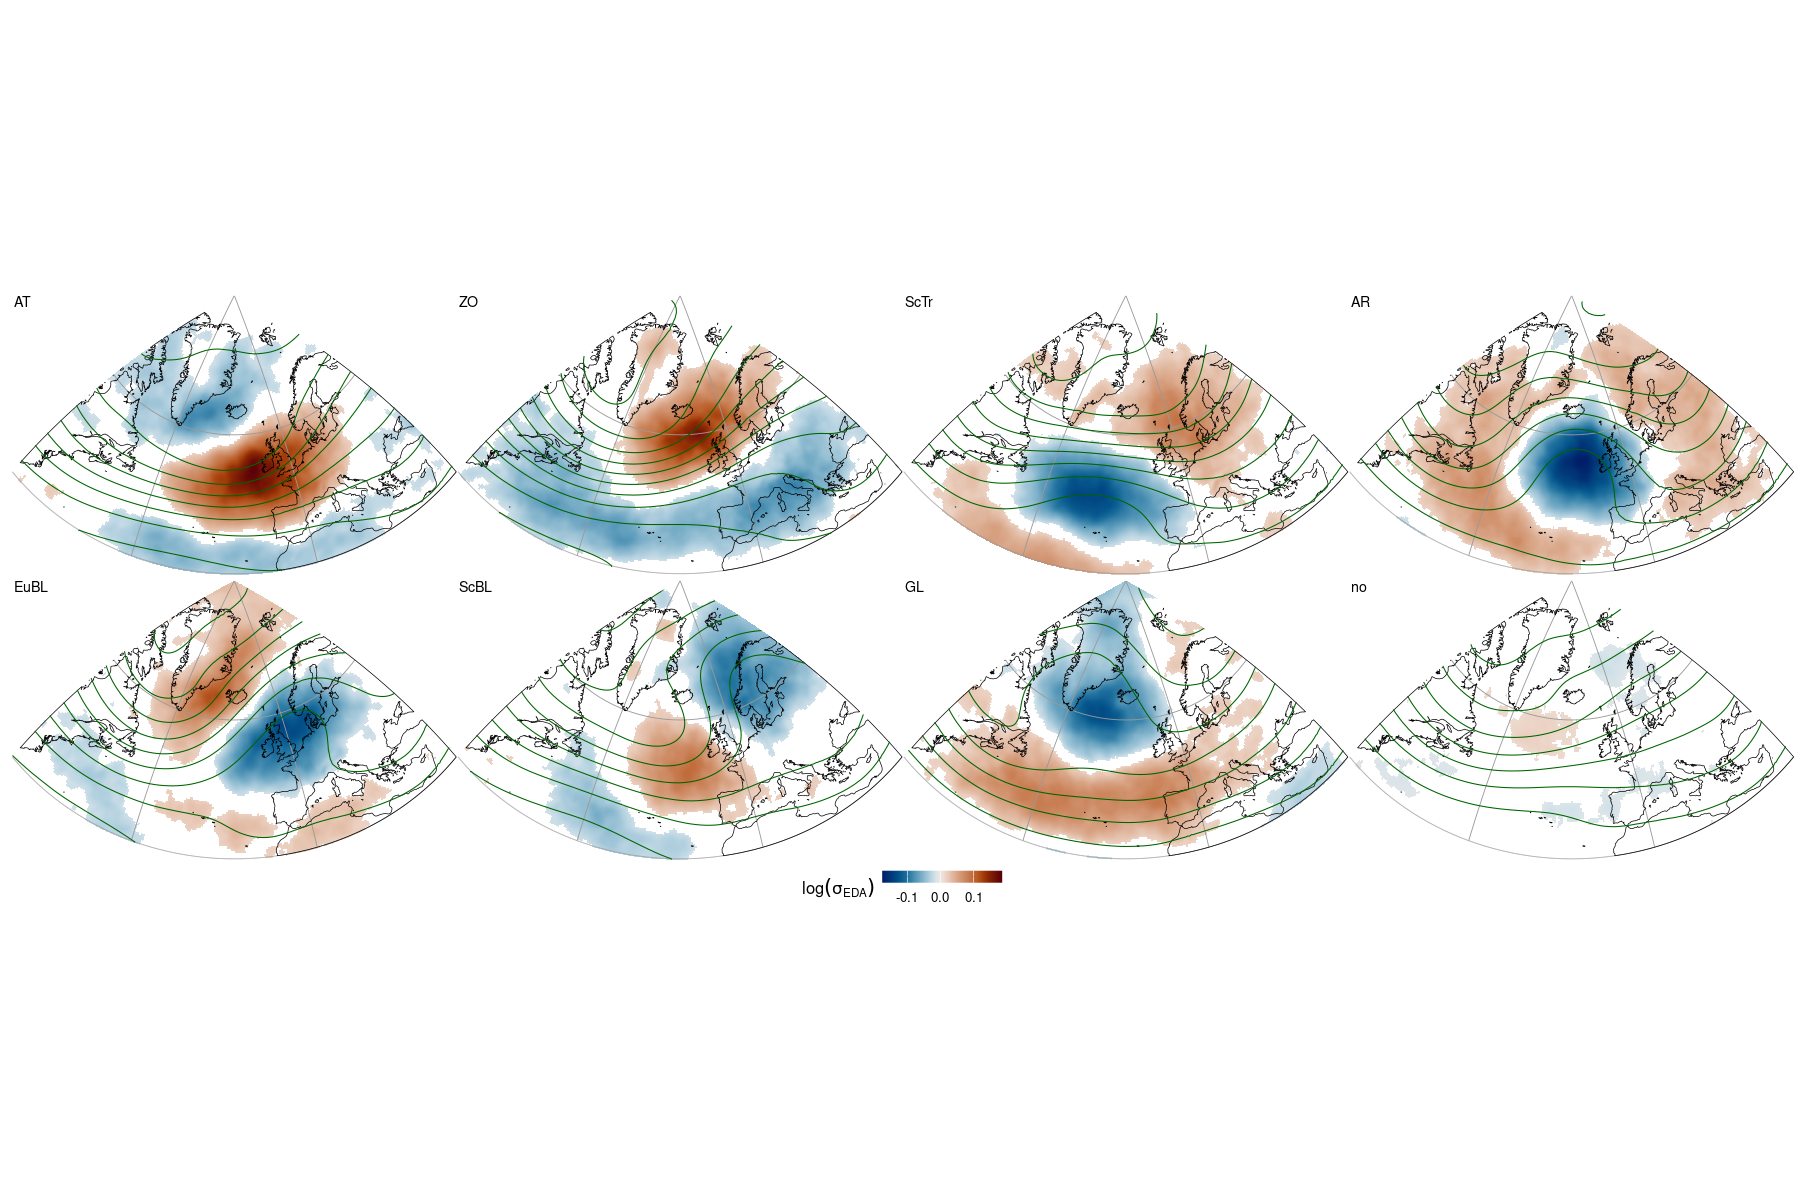

In [6]:
p
save_plot(p, "RegimeComposite.pdf", width = 7, height = 3.5, tight = FALSE)


although coordinates are longitude/latitude, st_union assumes that they are
planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


pdf 
  2

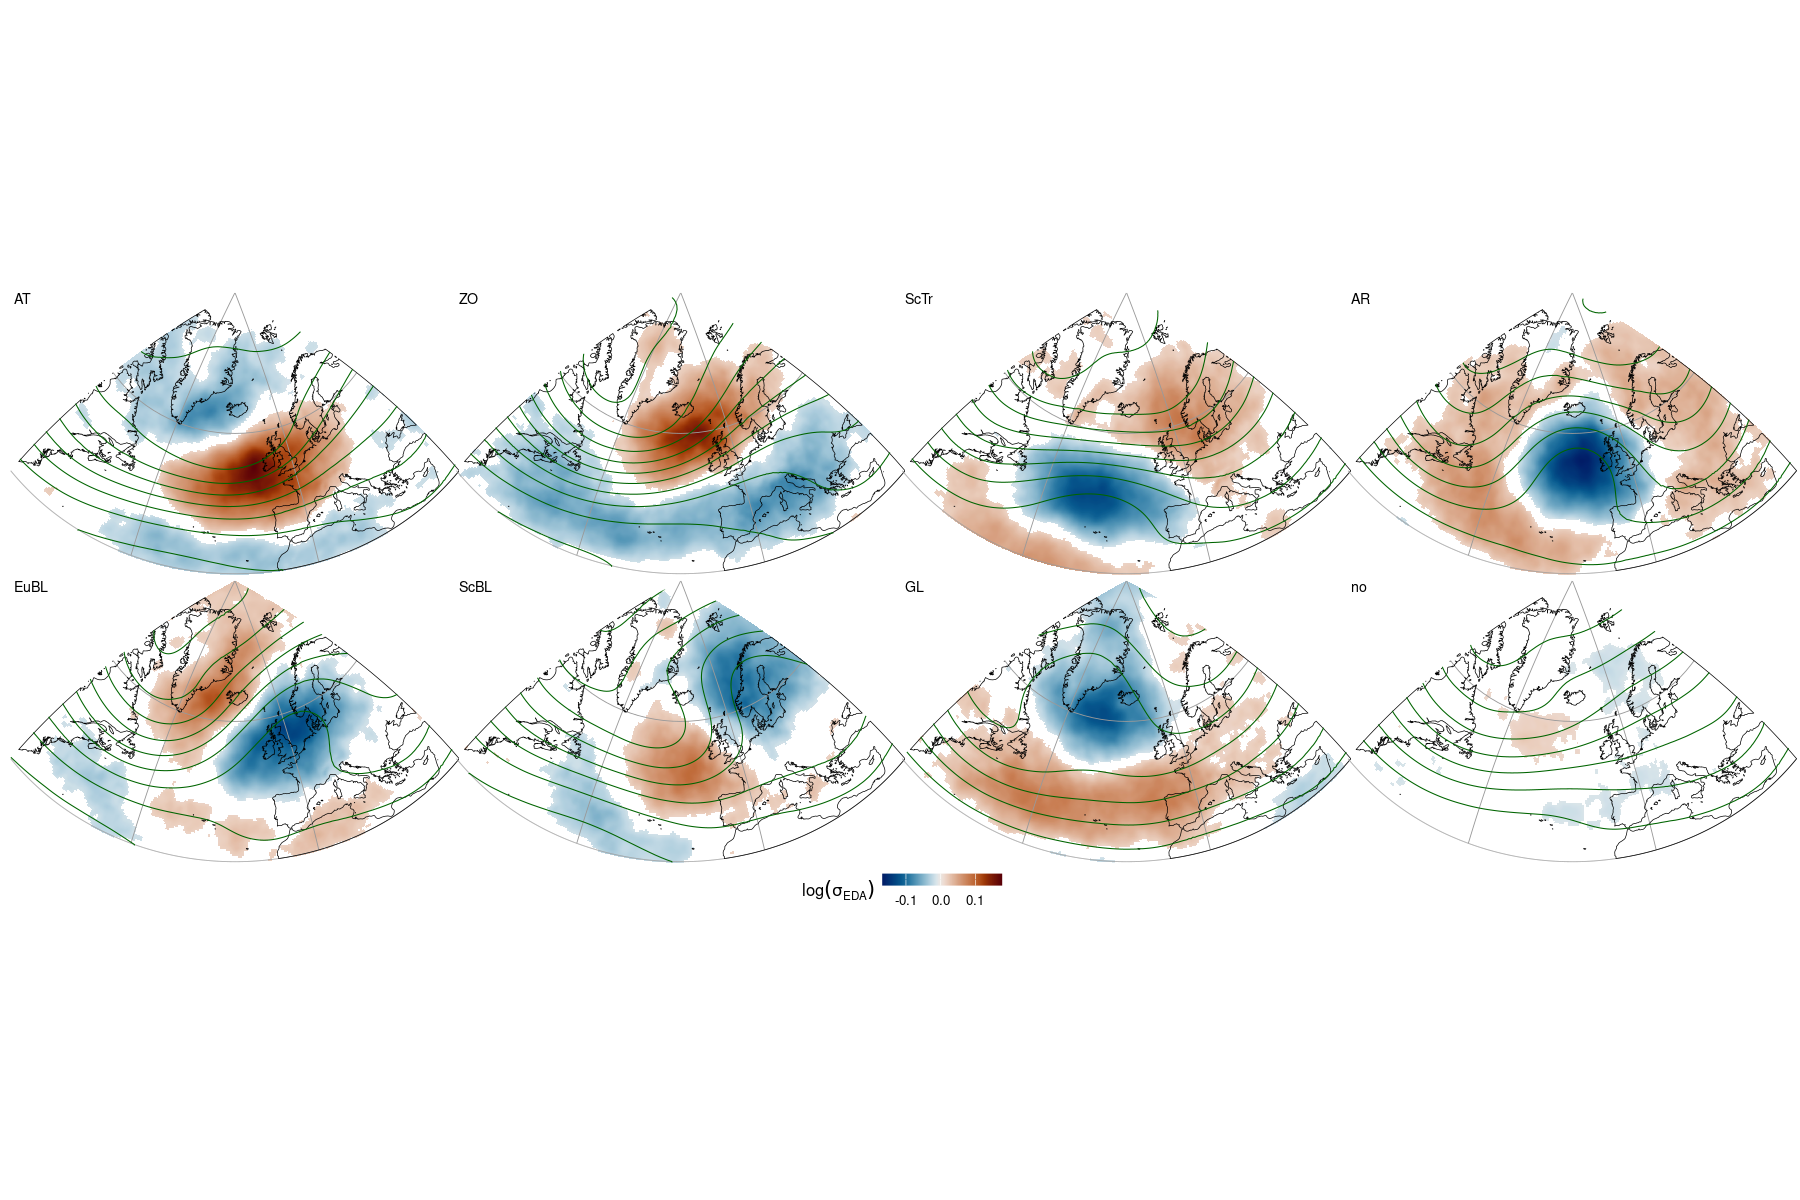

In [15]:
p <- plot_map_faceted(
    df = comp_df_emm,
    var = composite_mean,
    facet_var = wrname,
    use_diverging = TRUE,
    p_val = p_value_adj,
    sig_threshold = 0.05,
    c_bar_label = "$\\log(\\sigma_{EDA})$",
    contour_var = z_g,
    contour_bin_width = 80,
    facet_nrow = 2
)

p
save_plot(p, "Regime1stEMM.pdf", width = 7, height = 3.5)


although coordinates are longitude/latitude, st_union assumes that they are
planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


pdf 
  2

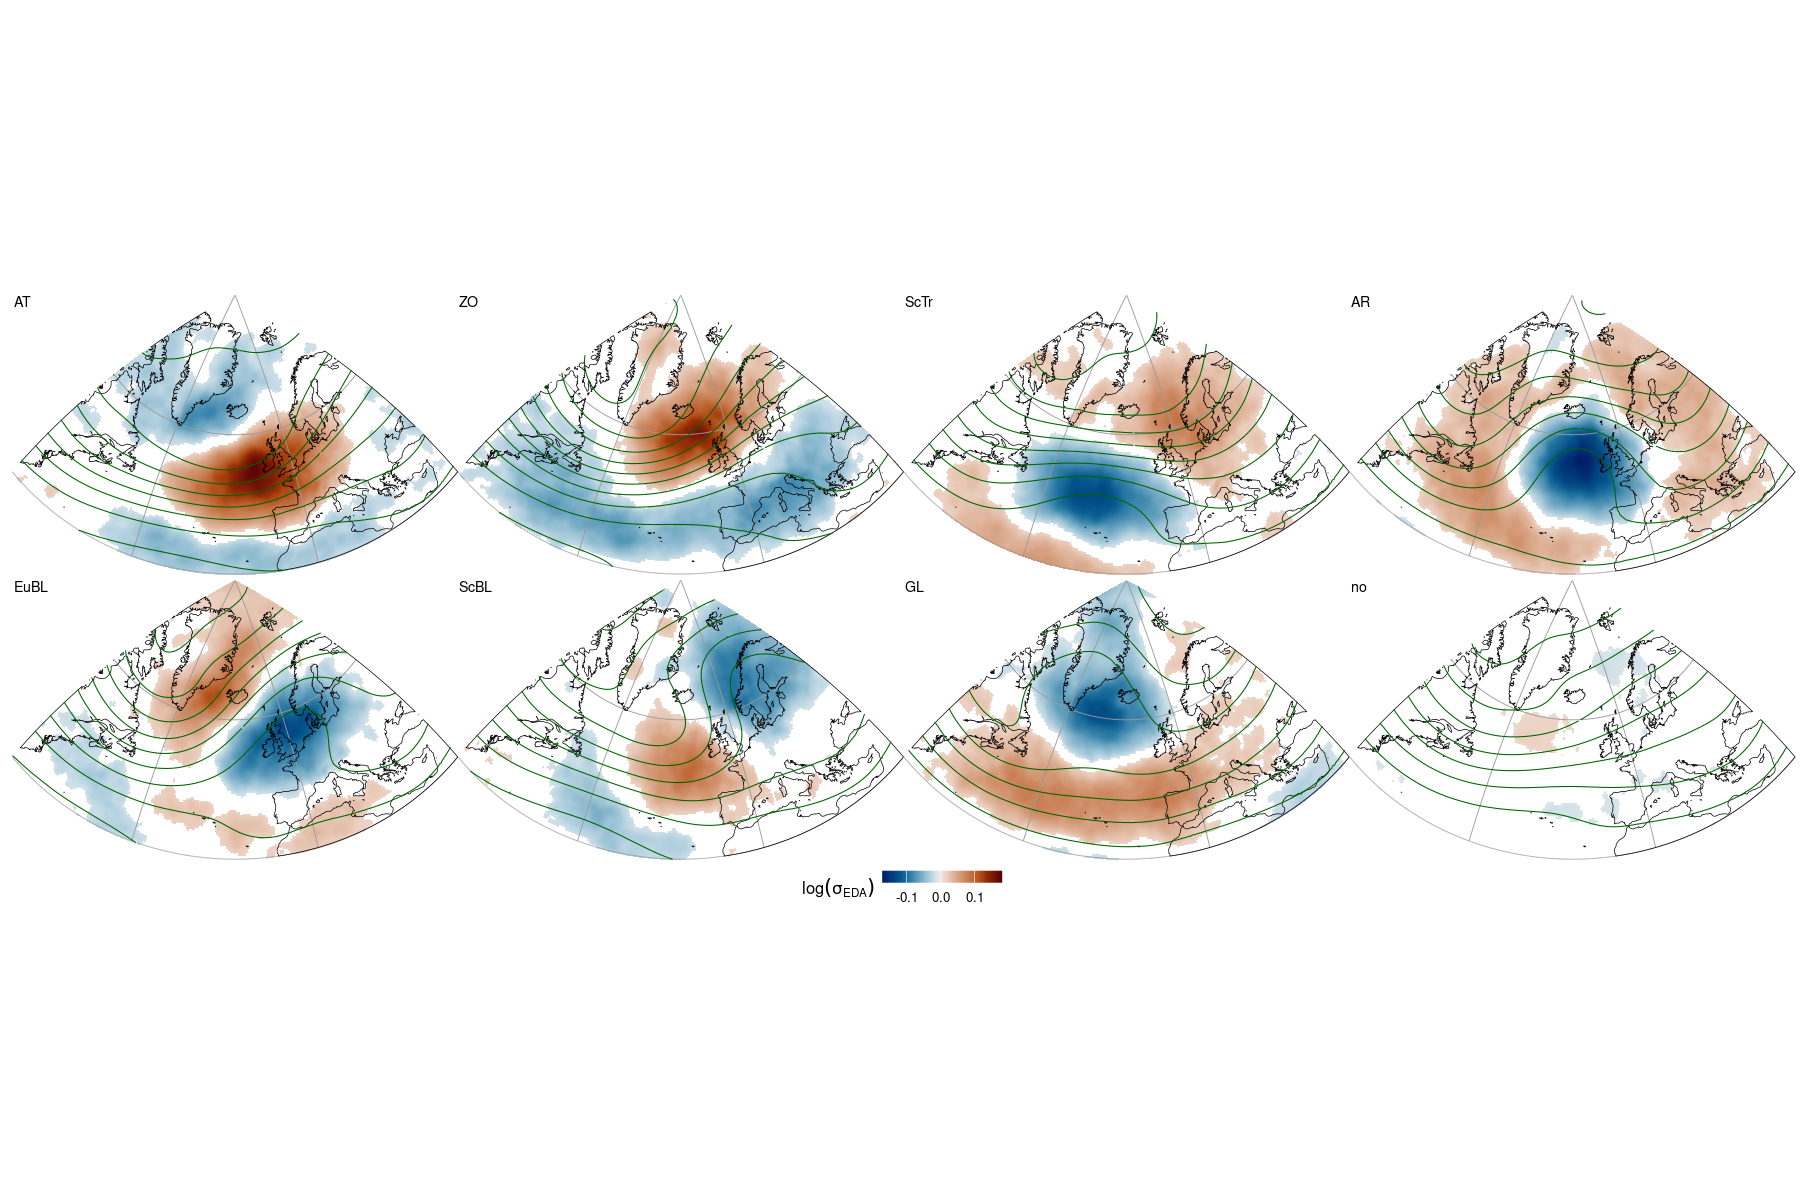

In [8]:
p <- plot_map_faceted(
    df = comp_df_emm2nd,
    var = emmean,
    facet_var = wrname,
    use_diverging = TRUE,
    p_val = p_value_adj,
    sig_threshold = 0.05,
    c_bar_label = "$\\log(\\sigma_{EDA})$",
    contour_var = z_g,
    contour_bin_width = 80,
    facet_nrow = 2
)

p
save_plot(p, "Regime2ndEMM.pdf", width = 7, height = 3.5)


In [ ]:
comp_df < -readRDS("../ens_data/composites_permutedSeg6.RDS")
str(comp_df)


tibble [68,728 × 7] (S3: tbl_df/tbl/data.frame)
 $ wr         : int [1:68728] 0 1 2 3 4 5 6 7 0 1 ...
 $ wrname     : chr [1:68728] "no" "AT" "AR" "GL" ...
 $ mean       : num [1:68728] -0.00921 0.01652 -0.05161 -0.02472 0.04574 ...
 $ p_value    : num [1:68728] 0.541 0.586 0.118 0.371 0.105 ...
 $ lon        : num [1:68728] -1 -1 -1 -1 -1 -1 -1 -1 -10 -10 ...
 $ lat        : num [1:68728] 20 20 20 20 20 20 20 20 20 20 ...
 $ p_value_adj: num [1:68728] 0.78 0.808 0.346 0.65 0.323 ...


In [ ]:
pps < -grid_and_legend(comp_df)

p < -combine_plots(pps[[1]], pps[[2]], "horizontal")
save_plot(p, "RegimesSeg6LargeH.pdf", width = 11.5, height = 5.5)


Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven ho

pdf 
  2

## For each grid point: what is the WR with the highest uncertainty?
1. For each grid point:
2. find highest "mean"
3. check if p_value_adj > 5%
4. return associated wr/wrname (factor)
5. plot at each grid point a different colour if sig., else blank

In [ ]:
# Create a new dataframe with the maximum mean value for each grid point
grid_max_df <- comp_df %>%
    # Filter for significant p-values first
    mutate(significant = p_value_adj < 0.05) %>%
    # Group by grid point
    group_by(lon, lat) %>%
    # Calculate max_wr and max_wrname
    summarize(
        # Find the wr with the maximum mean, set to NA if no significant values
        max_wr = if (any(significant)) {
            wr[which.max(ifelse(significant, mean, -Inf))]
        } else {
            NA_integer_
        },
        # Find the wrname with the maximum mean, set to NA if no significant values
        max_wrname = if (any(significant)) {
            wrname[which.max(ifelse(significant, mean, -Inf))]
        } else {
            NA_character_
        },
        min_wr = if (any(significant)) {
            wr[which.min(ifelse(significant, mean, Inf))]
        } else {
            NA_integer_
        },
        # Find the wrname with the maximum mean, set to NA if no significant values
        min_wrname = if (any(significant)) {
            wrname[which.min(ifelse(significant, mean, Inf))]
        } else {
            NA_character_
        }
    ) %>%
    ungroup()

str(grid_max_df)


`summarise()` has grouped output by 'lon'. You can override using the `.groups`
argument.


tibble [8,591 × 6] (S3: tbl_df/tbl/data.frame)
 $ lon       : num [1:8591] -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 ...
 $ lat       : num [1:8591] 20 21 22 23 24 25 26 27 28 29 ...
 $ max_wr    : int [1:8591] NA NA NA NA NA NA NA NA NA 7 ...
 $ max_wrname: chr [1:8591] NA NA NA NA ...
 $ min_wr    : int [1:8591] NA NA NA NA NA NA NA NA NA 7 ...
 $ min_wrname: chr [1:8591] NA NA NA NA ...


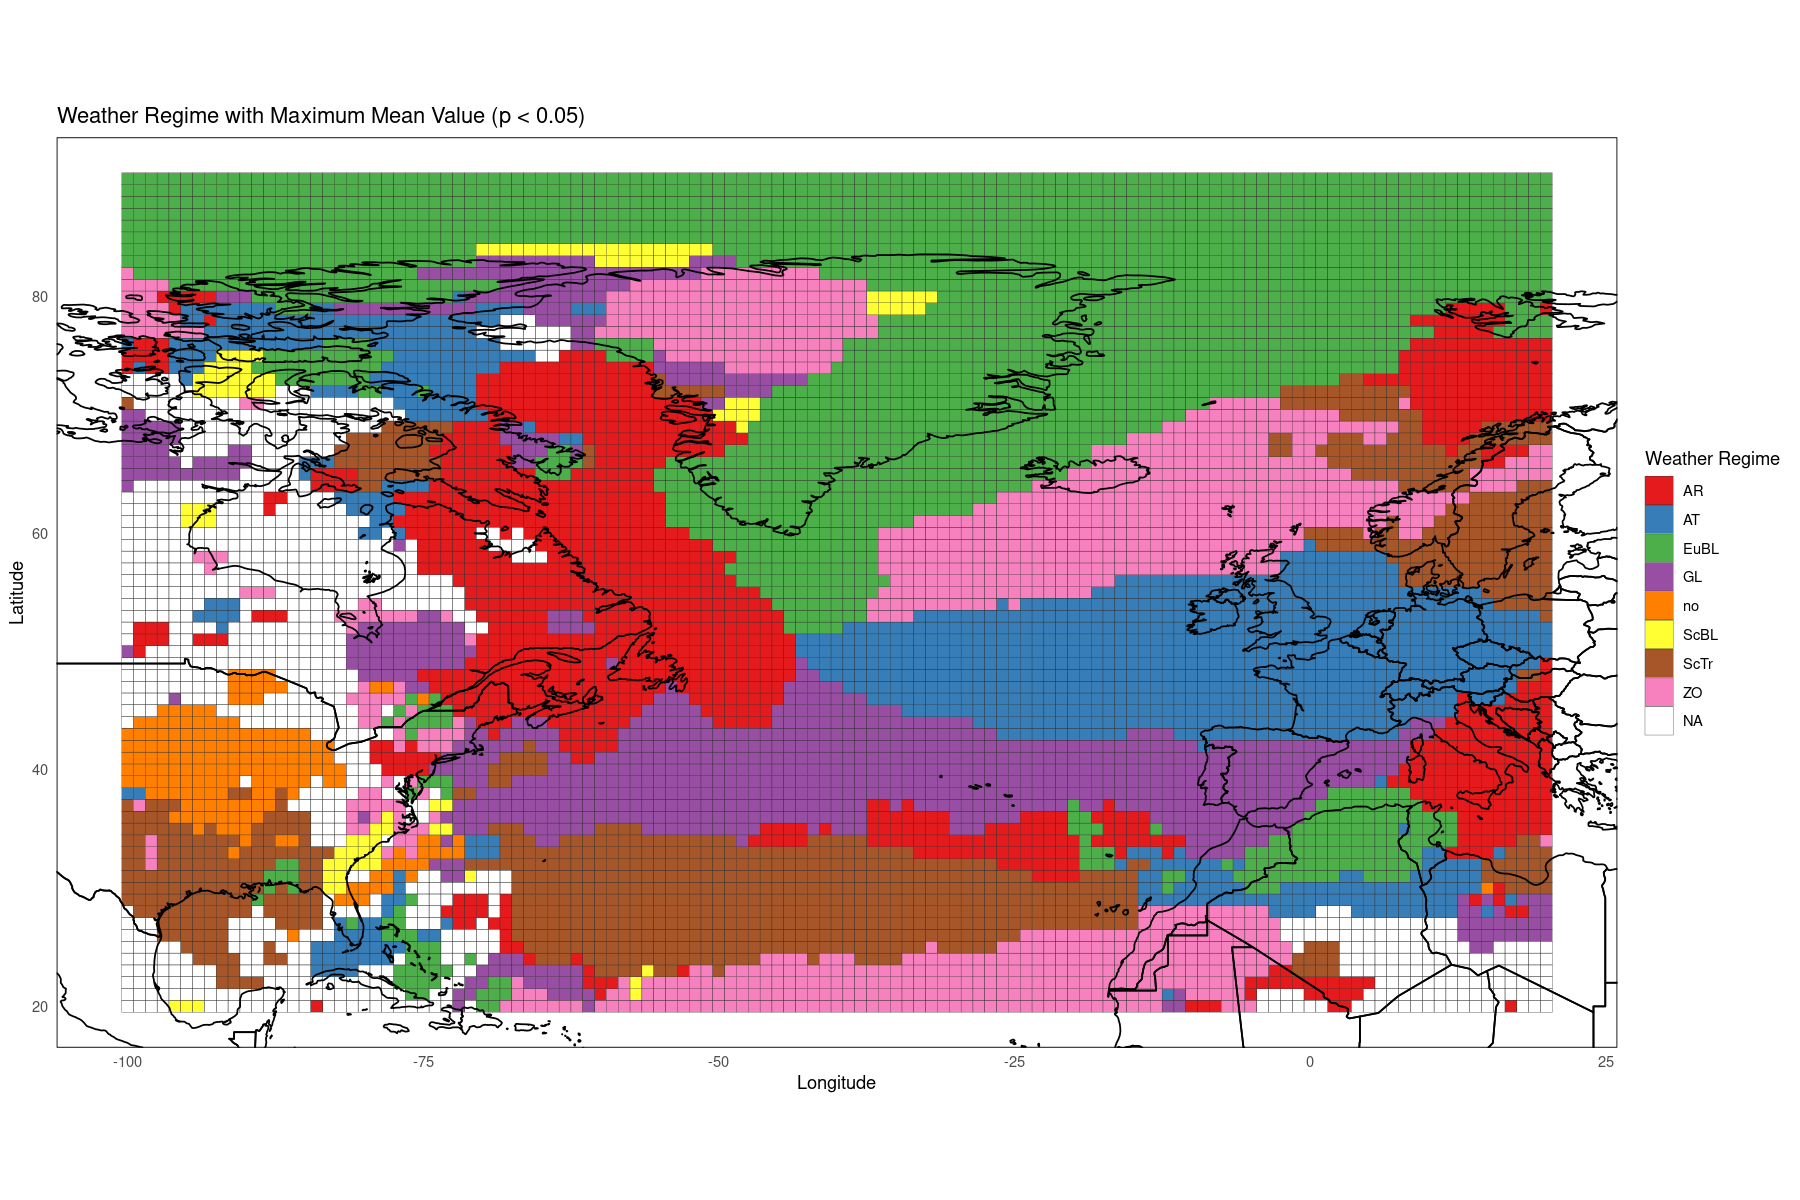

In [ ]:
# Load necessary libraries
library(ggplot2)
library(dplyr)
library(RColorBrewer)
library(maps)

# Count the number of unique wrnames (excluding NA)
n_regimes <- length(unique(na.omit(grid_max_df$max_wrname)))

# Create a color palette with enough colors
if (n_regimes <= 8) {
    colors <- brewer.pal(max(3, n_regimes), "Set1")
} else {
    colors <- colorRampPalette(brewer.pal(8, "Set1"))(n_regimes)
}

# Get world map data for the coastlines
world_map <- map_data("world")

# Create the plot
regime_plot <- ggplot() +
    # Add the grid cells with geom_tile
    geom_tile(
        data = grid_max_df, aes(x = lon, y = lat, fill = max_wrname),
        color = "gray20", linewidth = 0.1
    ) +
    # Add coastlines
    geom_polygon(
        data = world_map, aes(x = long, y = lat, group = group),
        fill = NA, color = "black", linewidth = 0.5
    ) +
    # Set the color scale with NA as transparent
    scale_fill_manual(values = colors, na.value = NA, name = "Weather Regime") +
    # Set appropriate coordinate limits based on your data
    # You may need to adjust these values to match your grid's extent
    coord_fixed(xlim = range(grid_max_df$lon), ylim = range(grid_max_df$lat)) +
    # Add labels and title
    labs(
        title = "Weather Regime with Maximum Mean Value (p < 0.05)",
        x = "Longitude",
        y = "Latitude"
    ) +
    # Customize the theme
    theme_minimal() +
    theme(
        legend.position = "right",
        panel.grid = element_blank(),
        panel.border = element_rect(fill = NA, color = "black")
    )

# Display the plot
print(regime_plot)

# Save the plot if needed
# ggsave("weather_regime_map.png", regime_plot, width = 10, height = 8, dpi = 300)


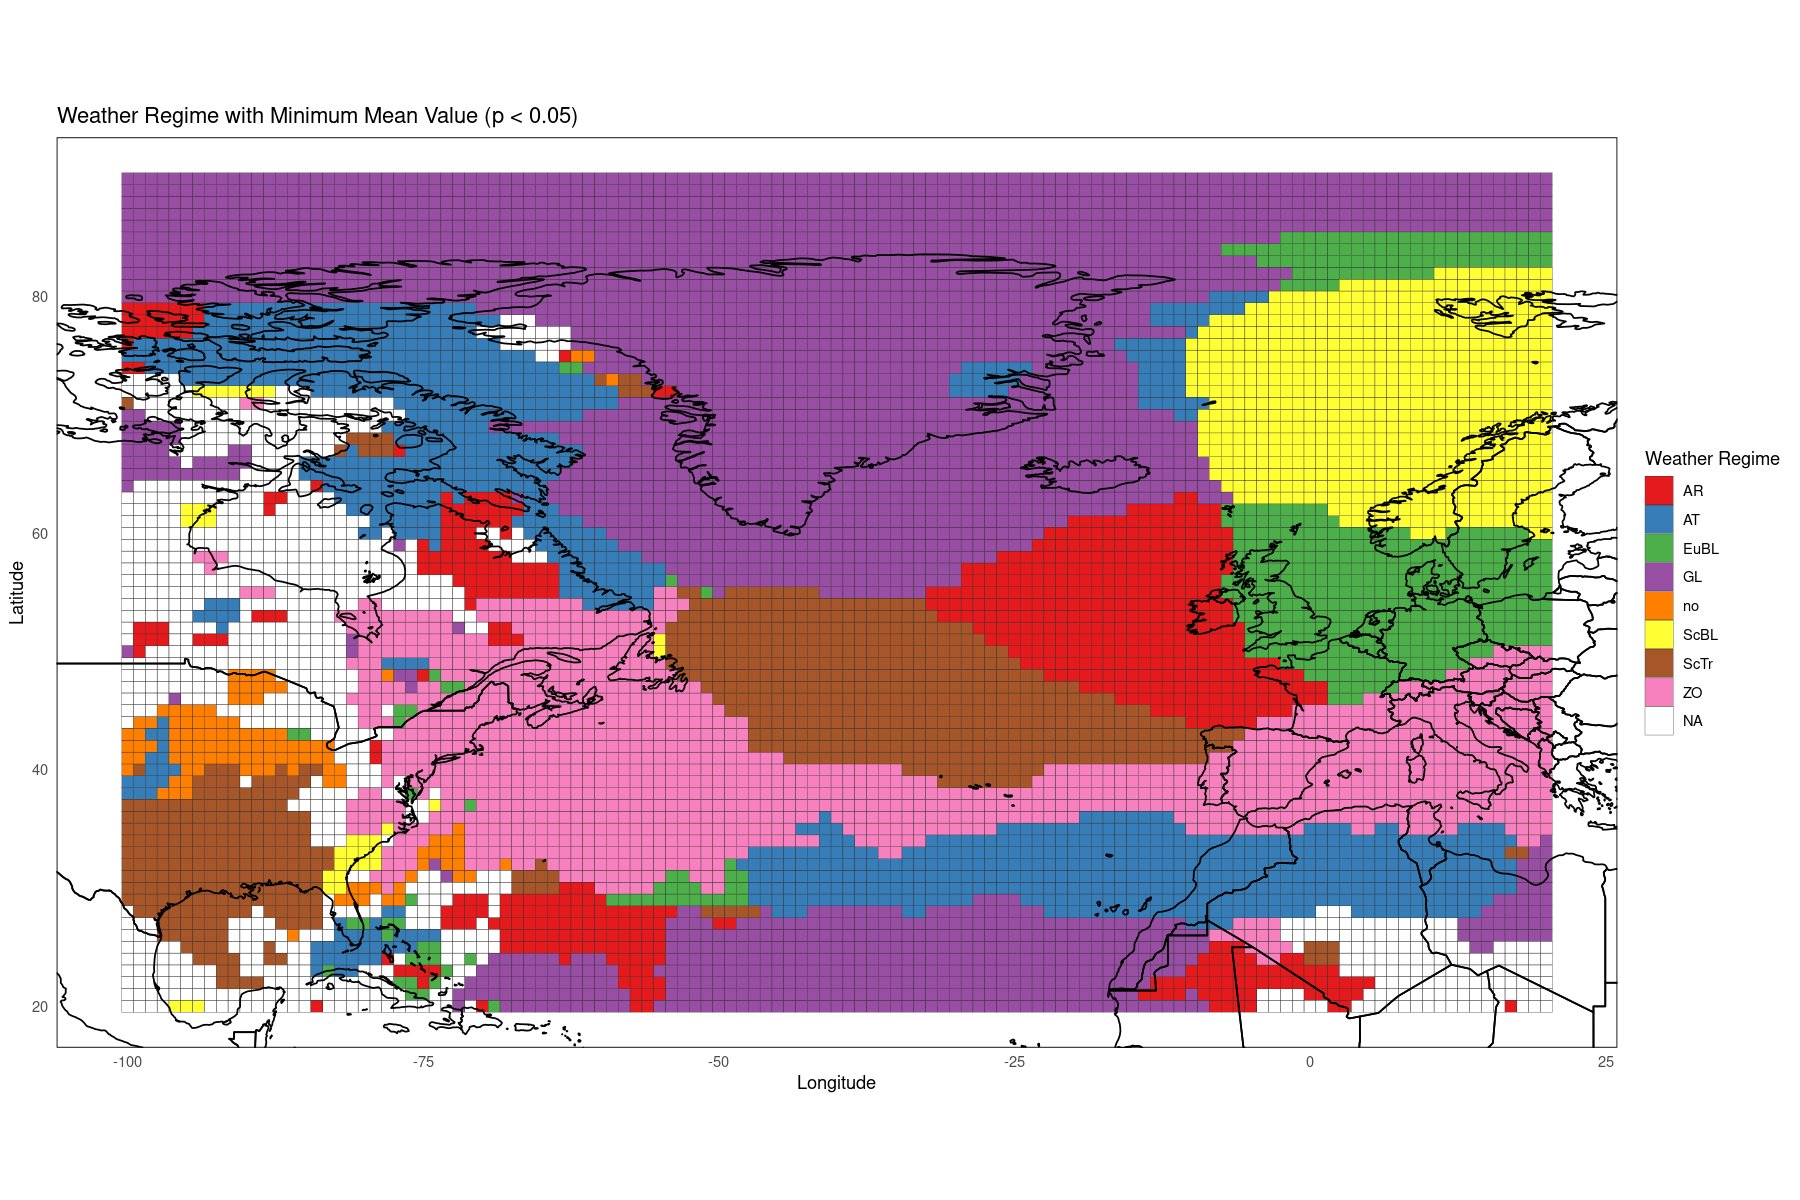

In [ ]:
# Create the plot
regime_plot <- ggplot() +
    # Add the grid cells with geom_tile
    geom_tile(
        data = grid_max_df, aes(x = lon, y = lat, fill = min_wrname),
        color = "gray20", linewidth = 0.1
    ) +
    # Add coastlines
    geom_polygon(
        data = world_map, aes(x = long, y = lat, group = group),
        fill = NA, color = "black", linewidth = 0.5
    ) +
    # Set the color scale with NA as transparent
    scale_fill_manual(values = colors, na.value = NA, name = "Weather Regime") +
    # Set appropriate coordinate limits based on your data
    # You may need to adjust these values to match your grid's extent
    coord_fixed(xlim = range(grid_max_df$lon), ylim = range(grid_max_df$lat)) +
    # Add labels and title
    labs(
        title = "Weather Regime with Minimum Mean Value (p < 0.05)",
        x = "Longitude",
        y = "Latitude"
    ) +
    # Customize the theme
    theme_minimal() +
    theme(
        legend.position = "right",
        panel.grid = element_blank(),
        panel.border = element_rect(fill = NA, color = "black")
    )

# Display the plot
print(regime_plot)


# Are WRs associated with higher/lower total uncertainty?

In [ ]:
residuals < -readRDS("../ens_data/residual_cube_weighted.rds")
str(residuals)


List of 5
 $ residuals  : num [1:241, 1:121, 1:31047] 0.15 0.174 0.202 0.216 0.22 ...
  ..- attr(*, "dimnames")=List of 3
  .. ..$ lon : chr [1:241] "-80" "-79.5" "-79" "-78.5" ...
  .. ..$ lat : chr [1:121] "30" "30.5" "31" "31.5" ...
  .. ..$ time: chr [1:31047] "1940-01-01" "1940-01-02" "1940-01-03" "1940-01-04" ...
 $ lon        : num [1:241] -80 -79.5 -79 -78.5 -78 -77.5 -77 -76.5 -76 -75.5 ...
 $ lat        : num [1:121] 30 30.5 31 31.5 32 32.5 33 33.5 34 34.5 ...
 $ time       : Date[1:31047], format: "1940-01-01" "1940-01-02" ...
 $ weight_mode: chr "stabilize"


In [ ]:
estimate_wr_mean_effects <- function(x, wr_min, CP) {
    library(emmeans)
    stopifnot(all(c("residuals", "lat", "time") %in% names(x)))
    stopifnot(all(c("date", "wrname") %in% names(wr_min)))

    # --- latitude-weighted spatial mean residual time series ---
    lat_w <- cos(x$lat * pi / 180)
    lat_w <- lat_w / sum(lat_w, na.rm = TRUE)

    # residuals dims: lon x lat x time
    # first average over lon within each latitude, then latitude-weight
    lonlat_mean <- apply(x$residuals, c(2, 3), mean, na.rm = TRUE) # lat x time
    res_mean <- as.numeric(colSums(lonlat_mean * lat_w, na.rm = TRUE))

    # --- build dataframe ---
    z_df <- data.frame(
        time = as.Date(x$time),
        resid_mean = res_mean
    )

    wr_min <- wr_min %>%
        mutate(date = as.Date(date))

    z_df <- z_df %>%
        left_join(wr_min, by = c("time" = "date")) %>%
        filter(!is.na(resid_mean), !is.na(wrname))

    # --- segment definition from global change points ---
    change_points <- as.Date(paste0(CP, "-01"), format = "%Y-%m-%d")
    cp_use <- sort(unique(change_points[
        change_points > min(z_df$time) & change_points < max(z_df$time)
    ]))

    z_df$segment <- factor(cut(
        z_df$time,
        breaks = c(min(z_df$time), cp_use, max(z_df$time) + 1),
        labels = FALSE,
        include.lowest = TRUE,
        right = FALSE
    ))

    z_df <- z_df %>%
        group_by(segment) %>%
        mutate(day_no = row_number()) %>%
        ungroup()

    z_df$wrname <- factor(z_df$wrname)

    # --- second-stage model: regime as sole predictor, AR1 within segment ---
    mod <- gls(
        resid_mean ~ wrname - 1,
        data = z_df,
        method = "REML",
        correlation = corAR1(form = ~ day_no | segment),
        na.action = na.omit
    )

    # --- emmeans per regime and tests against 0 ---
    emm <- emmeans(mod, ~wrname)
    emm_df <- as.data.frame(summary(emm, infer = c(TRUE, TRUE), null = 0))

    # adjusted p-values across regimes
    emm_df$adjusted_pvalue <- p.adjust(emm_df$p.value, method = "fdr")

    # final output
    out <- emm_df %>%
        transmute(
            wrname = as.character(wrname),
            emmeans_effect = emmean,
            lower_ci = lower.CL,
            upper_ci = upper.CL,
            pvalue = p.value,
            adjusted_pvalue = adjusted_pvalue
        )

    list(
        data = z_df,
        model = mod,
        results = out
    )
}


In [ ]:
areamean < -estimate_wr_mean_effects(residuals, wr_min = wr_min, CP = CP)


In [ ]:
str(areamean$results)


'data.frame':	8 obs. of  6 variables:
 $ wrname         : chr  "AT" "ZO" "ScTr" "AR" ...
 $ emmeans_effect : num  0.00165 -0.00363 0.00104 0.00526 -0.00179 ...
 $ lower_ci       : num  -0.00152 -0.00692 -0.00193 0.00216 -0.00488 ...
 $ upper_ci       : num  0.00483 -0.000338 0.004015 0.008364 0.001302 ...
 $ pvalue         : num  0.307937 0.030671 0.49223 0.000897 0.256689 ...
 $ adjusted_pvalue: num  0.35193 0.06134 0.49223 0.00717 0.34225 ...


pdf 
  2

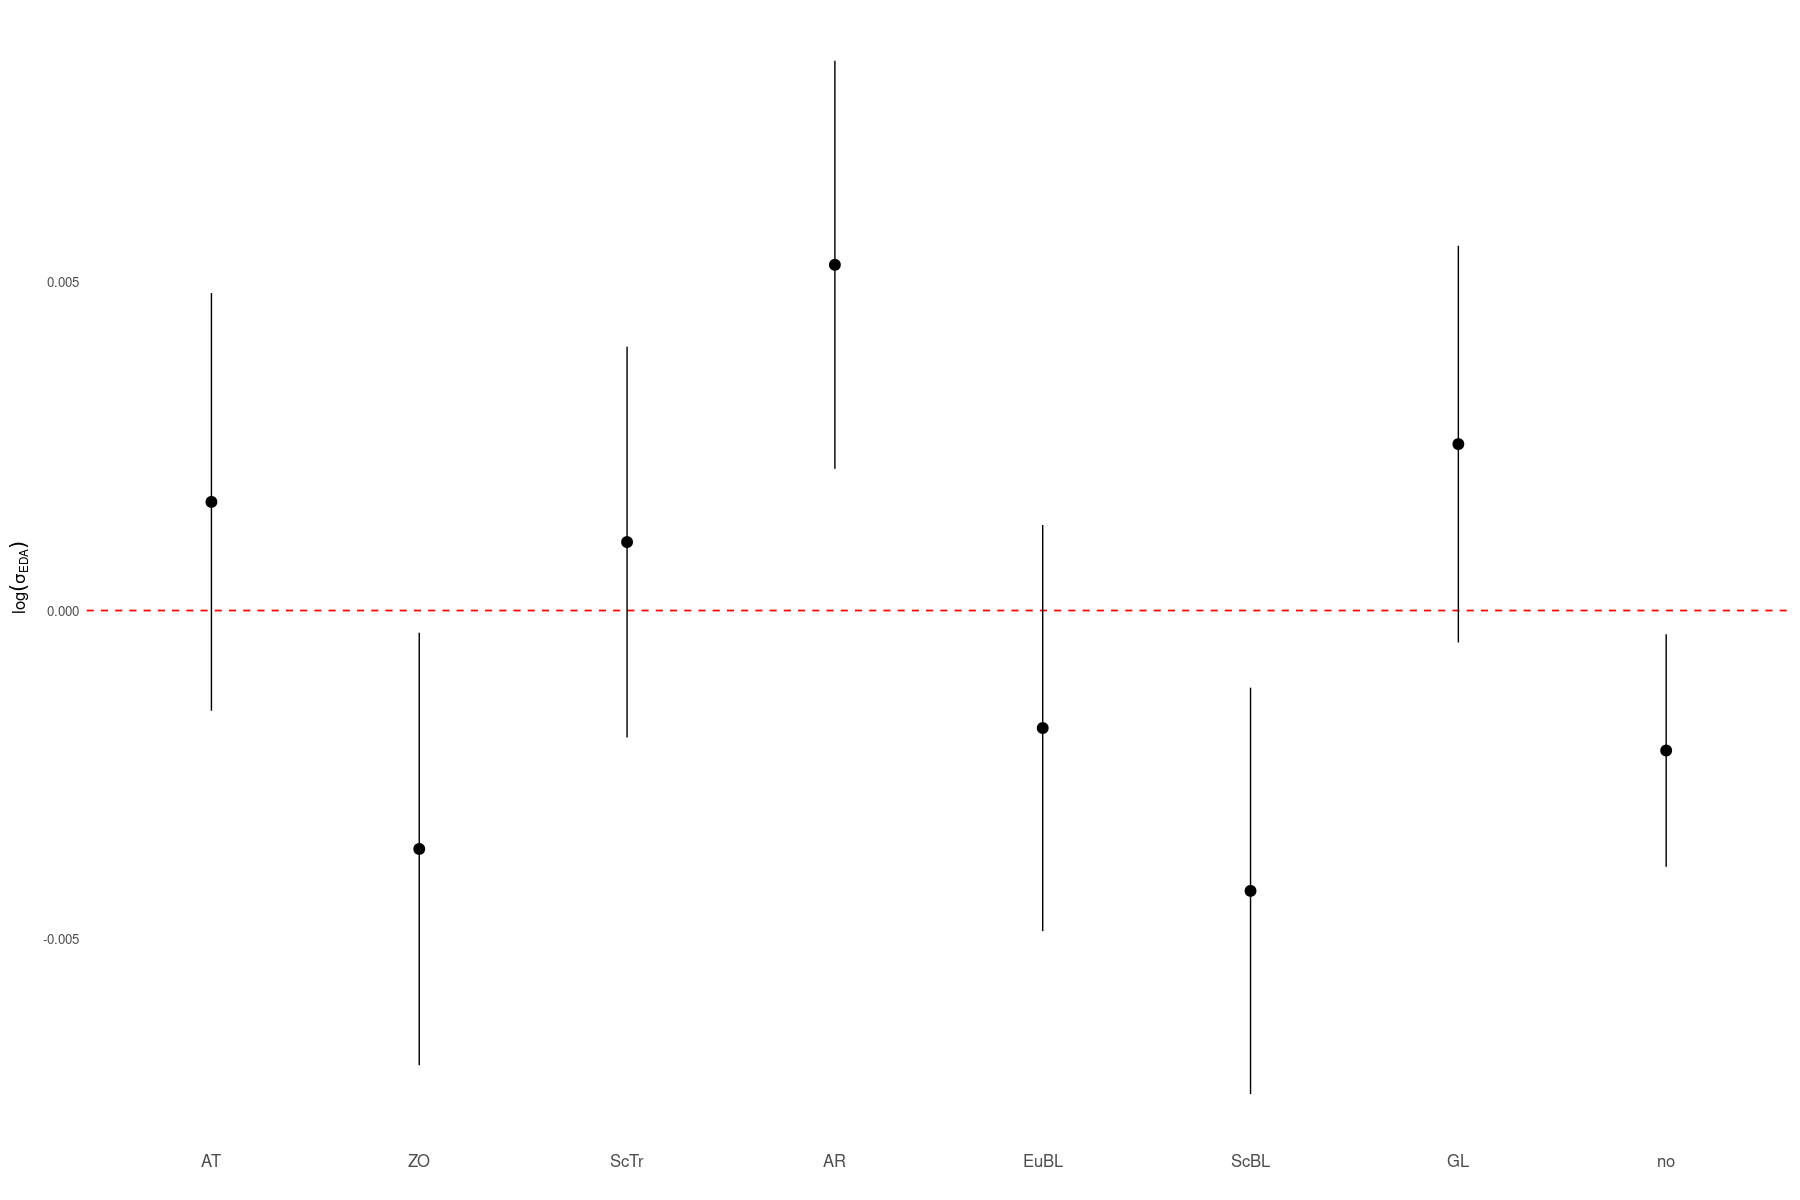

In [ ]:
WR_ORDER <- c("AT", "ZO", "ScTr", "AR", "EuBL", "ScBL", "GL", "no")

plot_df <- areamean$results %>%
    mutate(wrname = factor(wrname, levels = WR_ORDER))

p <- ggplot(plot_df, aes(x = wrname, y = emmeans_effect)) +
    geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.5, color = "red") +
    geom_pointrange(aes(ymin = lower_ci, ymax = upper_ci), linewidth = 0.4) +
    labs(
        x = "",
        y = TeX("$\\log(\\sigma_{EDA})$")
    ) +
    THEME_PUB +
    theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

p
save_plot(p, "AreaMeanEMM.pdf", width = 4, height = 3)


## make lms with WRs work


In [ ]:
wr_min %>% str()


'data.frame':	27397 obs. of  2 variables:
 $ date  : Date, format: "1950-01-11" "1950-01-12" ...
 $ wrname: Factor w/ 8 levels "AT","ZO","ScTr",..: 8 8 8 8 8 8 5 5 5 5 ...


In [ ]:
wr_min <- readRDS("/home/schoelleh96/wp22a/data/wrnames.rds")
wr_min$date <- as.Date(wr_min$date)
nc_file <- nc_open("/net/scratch/schoelleh96/WP2/WP2.2a/ens_data/geopotential.nc")
print("Data opened; reading z")
z_data <- ncvar_get(nc_file, "z", collapse_degen = FALSE)
print("reading latlon")
# Get coordinates
lon_data <- ncvar_get(nc_file, "longitude")
lat_data <- ncvar_get(nc_file, "latitude")
print(lat_data)
print(lon_data)
grid_points <- expand.grid(1:length(lon_data), 1:length(lat_data))
print("reading time")
time_data <- ncvar_get(nc_file, "valid_time")

# Convert time
time_origin <- sub(
    "seconds since ", "",
    ncatt_get(nc_file, "valid_time", "units")$value
)
time <- as.Date(as.POSIXct(time_data, origin = time_origin, tz = "UTC"))
years <- as.integer(format(time, "%Y"))
year_idx <- which(years >= YEAR_BOUND_WR[1] & years <= YEAR_BOUND_WR[2])

time <- time[year_idx]
z_data <- z_data[, , year_idx, drop = FALSE]

nc_close(nc_file)
print("Data read")


[1] "Data opened; reading z"
[1] "reading latlon"
  [1] 90.0 89.5 89.0 88.5 88.0 87.5 87.0 86.5 86.0 85.5 85.0 84.5 84.0 83.5 83.0
 [16] 82.5 82.0 81.5 81.0 80.5 80.0 79.5 79.0 78.5 78.0 77.5 77.0 76.5 76.0 75.5
 [31] 75.0 74.5 74.0 73.5 73.0 72.5 72.0 71.5 71.0 70.5 70.0 69.5 69.0 68.5 68.0
 [46] 67.5 67.0 66.5 66.0 65.5 65.0 64.5 64.0 63.5 63.0 62.5 62.0 61.5 61.0 60.5
 [61] 60.0 59.5 59.0 58.5 58.0 57.5 57.0 56.5 56.0 55.5 55.0 54.5 54.0 53.5 53.0
 [76] 52.5 52.0 51.5 51.0 50.5 50.0 49.5 49.0 48.5 48.0 47.5 47.0 46.5 46.0 45.5
 [91] 45.0 44.5 44.0 43.5 43.0 42.5 42.0 41.5 41.0 40.5 40.0 39.5 39.0 38.5 38.0
[106] 37.5 37.0 36.5 36.0 35.5 35.0 34.5 34.0 33.5 33.0 32.5 32.0 31.5 31.0 30.5
[121] 30.0
  [1] -80.0 -79.5 -79.0 -78.5 -78.0 -77.5 -77.0 -76.5 -76.0 -75.5 -75.0 -74.5
 [13] -74.0 -73.5 -73.0 -72.5 -72.0 -71.5 -71.0 -70.5 -70.0 -69.5 -69.0 -68.5
 [25] -68.0 -67.5 -67.0 -66.5 -66.0 -65.5 -65.0 -64.5 -64.0 -63.5 -63.0 -62.5
 [37] -62.0 -61.5 -61.0 -60.5 -60.0 -59.5 -59.0 -58.5 -58

In [ ]:
i <- 1
lon_idx <- grid_points[i, 1]
lat_idx <- grid_points[i, 2]
print(paste0("Processing grid point ", lat_idx, ", ", lon_idx))
print(paste0(
    "Lat: ", lat_data[lat_idx],
    ", Lon: ", lon_data[lon_idx]
))
lat <- lat_data[lat_idx]
lon <- lon_data[lon_idx]
z <- z_data[lon_idx, lat_idx, ]
cps <- change_points <- as.Date(paste0(CP, "-01"), format = "%Y-%m-%d")
wrs <- wr_min


[1] "Processing grid point 1, 1"
[1] "Lat: 90, Lon: -80"


In [ ]:
print("pull data together")

z_df <- data.frame(time = time, z = z)
print("Data frame created")
z_df$year <- as.integer(format(z_df$time, "%Y"))
z_df$doy <- as.integer(format(z_df$time, "%j"))
print("now combine")

z_df$sin_doy <- sin(2 * pi * z_df$doy / 365)
z_df$cos_doy <- cos(2 * pi * z_df$doy / 365)
z_df <- dplyr::inner_join(
    z_df,
    wrs,
    by = c("time" = "date")
)
str(z_df)


[1] "pull data together"
[1] "Data frame created"


[1] "now combine"
'data.frame':	27384 obs. of  7 variables:
 $ time   : Date, format: "1950-01-11" "1950-01-12" ...
 $ z      : num  124 439 331 184 138 ...
 $ year   : int  1950 1950 1950 1950 1950 1950 1950 1950 1950 1950 ...
 $ doy    : int  11 12 13 14 15 16 17 18 19 20 ...
 $ sin_doy: num  0.188 0.205 0.222 0.239 0.255 ...
 $ cos_doy: num  0.982 0.979 0.975 0.971 0.967 ...
 $ wrname : Factor w/ 8 levels "AT","ZO","ScTr",..: 8 8 8 8 8 8 5 5 5 5 ...


In [ ]:
z_df$log_variance <- log(z_df$z)


z_df$segment <- cut(as.Date(z_df$time),
    breaks = c(as.Date(c(
        z_df$time[1],
        cps,
        z_df$time[nrow(z_df)]
    ))),
    labels = 0:(length(cps)) + 1,
    include.lowest = TRUE,
    right = FALSE
)
z_df <- z_df %>%
    group_by(segment) %>%
    mutate(day_no = row_number()) %>%
    ungroup()


In [ ]:
rhs <- c(
    "segment",
    "segment:year",
    "segment:sin_doy + segment:cos_doy"
)
rhs <- c(rhs, "wrname")
fml <- as.formula(
    paste0("log_variance ~ ", paste(rhs, collapse = " + "), " - 1")
)


In [ ]:
lmod_seas <- nlme::gls(
    fml,
    data = z_df,
    correlation = corAR1(form = ~ day_no | segment),
    weights = varIdent(form = ~ 1 | segment)
)


In [ ]:
z_df$segment %>% unique()


[1] 2 3 4 5 6
Levels: 1 2 3 4 5 6

In [ ]:
fml


log_variance ~ segment + segment:year + segment:sin_doy + segment:cos_doy + 
    wrname - 1

In [ ]:
lmod_seas$data <- z_df
